In [1]:
import torch
import numpy as np
import deepwave
from Module26Gaussian import *
import math
import scipy.ndimage
import matplotlib.pyplot as plt
from gaussian_blur import LowFrequencyExtractor
from domain_discriminator import DomainDiscriminator2D

In [2]:
def set_seed(seed=99):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(99)

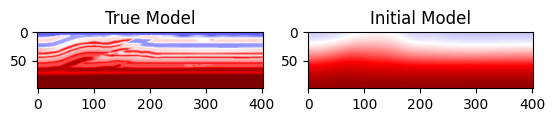

In [19]:
freq = 10
dx = 20
dt = 0.001
nt = 2000
nz = 100
nx = 401
num_shots = 40
source_spacing = 10
device = torch.device('cuda:0')
true_model = np.load('overthrust.npy')
model_init = scipy.ndimage.gaussian_filter(true_model,sigma=20)
plt.subplot(1,2,1)
plt.imshow(true_model,cmap='seismic',vmin=600,vmax=6000)
plt.title("True Model")
plt.subplot(1,2,2)
plt.imshow(model_init,cmap='seismic',vmin=600,vmax=6000)
plt.title("Initial Model")
plt.show()
true_model = torch.tensor(true_model,dtype=torch.float32, device=device)
model_init = torch.tensor(model_init,dtype=torch.float32, device=device)

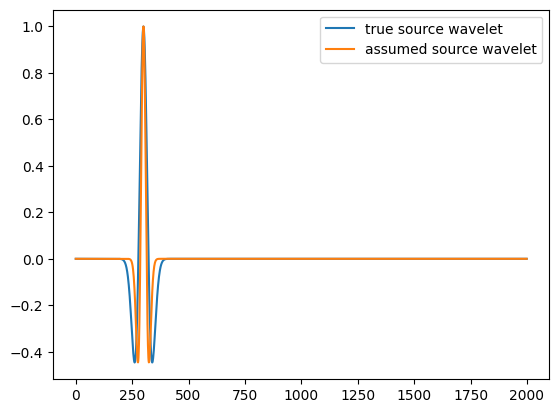

In [4]:
source_l = torch.zeros(num_shots,1,2)
source_l[:, 0, 1] = (1.0+torch.arange(num_shots)).float() * source_spacing
receiver_l = torch.zeros(num_shots, 400,2)
receiver_l[0, :, 1] = torch.arange(400).float() * 1
receiver_l[:, :, 1] = receiver_l[0, :, 1].repeat(num_shots, 1)
source_amplitude_true = deepwave.wavelets.ricker(freq, nt, dt, 0.3).reshape(1, 1, -1)
source_amplitude_assumed = deepwave.wavelets.ricker(16, nt, dt, 0.3).reshape(1, 1, -1)
source_func_true = source_amplitude_true.repeat(num_shots,1,1)
source_func_assumed = source_amplitude_assumed.repeat(num_shots,1,1)
plt.plot(source_amplitude_true.detach().cpu().numpy()[0,0,:],label="true source wavelet")
plt.plot(source_amplitude_assumed.detach().cpu().numpy()[0,0,:],label="assumed source wavelet")
plt.legend()
plt.show()

In [5]:
receiver_amplitudes_true = deepwave.scalar(
    true_model.to(device),
    dx,
    dt,
    source_amplitudes=source_func_true.to(device),
    source_locations=source_l.to(device),
    receiver_locations=receiver_l.to(device)
)[-1]

In [6]:
model_fwi = model_init.clone().detach().to(device).requires_grad_(True)
opt_fwi = torch.optim.Adam([{'params':[model_fwi], 'lr':30, 'weight_decay':0e-11}])
model_fwi = model_fwi.to(device)
model_fwi.requires_grad = True
num_batches = 8
num_shots_per_batch = int(num_shots / num_batches)
num_epochs = 100

In [10]:
for epoch in range(200):
    epoch_loss = 0.0

    for it in range(num_batches):
        opt_fwi.zero_grad()
        batch_src_amps = source_amplitude_assumed.repeat(num_shots_per_batch, 1, 1)
        batch_rcv_amps_true = receiver_amplitudes_true[it::num_batches].to(device)

        batch_x_s = source_l[it::num_batches].to(device)
        batch_x_r = receiver_l[it::num_batches].to(device)

        batch_rcv_amps_pred = deepwave.scalar(
            model_fwi.to(device),
            dx,
            dt,
            source_amplitudes=batch_src_amps.to(device),
            source_locations=batch_x_s.to(device),
            receiver_locations=batch_x_r.to(device)
        )[-1]

        u_obs = batch_rcv_amps_true / torch.sqrt(torch.mul(batch_rcv_amps_true, batch_rcv_amps_true).sum())
        u_pred = batch_rcv_amps_pred / torch.sqrt(torch.mul(batch_rcv_amps_pred, batch_rcv_amps_pred).sum())

        loss = -torch.sum(torch.mul(u_obs, u_pred))

        #loss = criterion(in_1,in_2)*1e9
        epoch_loss += loss.item()
        loss.backward()
        opt_fwi.step()

    print('current epoch: %d,loss: %.6f' % (epoch, loss))

current epoch: 0,loss: -0.337841
current epoch: 1,loss: -0.374594
current epoch: 2,loss: -0.429185
current epoch: 3,loss: -0.502986
current epoch: 4,loss: -0.551048
current epoch: 5,loss: -0.595958
current epoch: 6,loss: -0.610961
current epoch: 7,loss: -0.620876
current epoch: 8,loss: -0.634963
current epoch: 9,loss: -0.649107
current epoch: 10,loss: -0.663736
current epoch: 11,loss: -0.681942
current epoch: 12,loss: -0.706749
current epoch: 13,loss: -0.732994
current epoch: 14,loss: -0.757661
current epoch: 15,loss: -0.783792
current epoch: 16,loss: -0.800403
current epoch: 17,loss: -0.811872
current epoch: 18,loss: -0.822967
current epoch: 19,loss: -0.831339
current epoch: 20,loss: -0.839751
current epoch: 21,loss: -0.844255
current epoch: 22,loss: -0.847778
current epoch: 23,loss: -0.852718
current epoch: 24,loss: -0.857535
current epoch: 25,loss: -0.864041
current epoch: 26,loss: -0.868358
current epoch: 27,loss: -0.869753
current epoch: 28,loss: -0.873517
current epoch: 29,loss: 

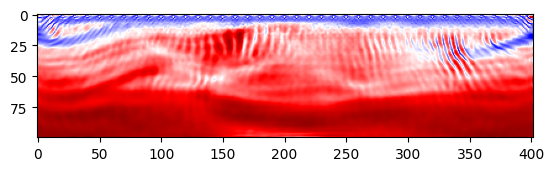

In [11]:
plt.imshow(model_fwi.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.show()

In [12]:
model_sia = model_init.clone().detach().to(device).requires_grad_(True)
opt_sia = torch.optim.Adam([{'params':[model_sia], 'lr':30, 'weight_decay':0e-11}])
model_sia = model_sia.to(device)
model_sia.requires_grad = True
Siamese = FrequencyAttentionFusion(5)
Siamese = Siamese.to(device)
optim_siamese = optim.Adam(Siamese.parameters(),lr=10e-4, betas=(0.5, 0.99), \
                    eps=1e-6, weight_decay=0)
low_extractor = LowFrequencyExtractor(pyramid_levels=2).to(device)

In [13]:
for epoch in range(100):
    epoch_loss = 0.0

    for it in range(num_batches):
        opt_sia.zero_grad()
        batch_src_amps = source_amplitude_assumed.repeat(num_shots_per_batch, 1, 1)
        batch_rcv_amps_true = receiver_amplitudes_true[it::num_batches].to(device)

        batch_x_s = source_l[it::num_batches].to(device)
        batch_x_r = receiver_l[it::num_batches].to(device)

        batch_rcv_amps_pred = deepwave.scalar(
            model_sia.to(device),
            dx,
            dt,
            source_amplitudes=batch_src_amps.to(device),
            source_locations=batch_x_s.to(device),
            receiver_locations=batch_x_r.to(device)
        )[-1]

        u_obs = batch_rcv_amps_true / torch.sqrt(torch.mul(batch_rcv_amps_true, batch_rcv_amps_true).sum())
        u_pred = batch_rcv_amps_pred / torch.sqrt(torch.mul(batch_rcv_amps_pred, batch_rcv_amps_pred).sum())

        u_obs = low_extractor(u_obs.unsqueeze(0))
        u_pred = low_extractor(u_pred.unsqueeze(0))
        output1, output2 = Siamese(u_obs, u_pred)
        loss = F.pairwise_distance(output1, output2, keepdim=True).mean()
        epoch_loss += loss.item()
        loss.backward()
        opt_sia.step()
        optim_siamese.step()
    print('current epoch: %d,loss: %.6f' % (epoch, loss))

current epoch: 0,loss: 0.011932
current epoch: 1,loss: 0.010548
current epoch: 2,loss: 0.008185
current epoch: 3,loss: 0.006809
current epoch: 4,loss: 0.006525
current epoch: 5,loss: 0.005077
current epoch: 6,loss: 0.003995
current epoch: 7,loss: 0.004718
current epoch: 8,loss: 0.007157
current epoch: 9,loss: 0.006927
current epoch: 10,loss: 0.012826
current epoch: 11,loss: 0.016488
current epoch: 12,loss: 0.017792
current epoch: 13,loss: 0.016030
current epoch: 14,loss: 0.060773
current epoch: 15,loss: 0.109330
current epoch: 16,loss: 0.065661
current epoch: 17,loss: 0.068328
current epoch: 18,loss: 0.068190
current epoch: 19,loss: 0.087308
current epoch: 20,loss: 0.083366
current epoch: 21,loss: 0.266221
current epoch: 22,loss: 0.150106
current epoch: 23,loss: 0.267024
current epoch: 24,loss: 0.110903
current epoch: 25,loss: 0.063183
current epoch: 26,loss: 0.094310
current epoch: 27,loss: 0.048578
current epoch: 28,loss: 0.133326
current epoch: 29,loss: 0.062325
current epoch: 30,lo

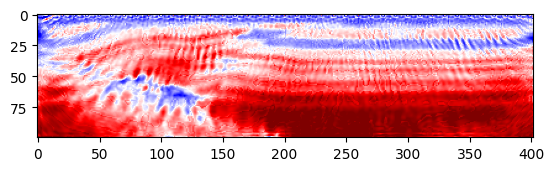

In [14]:
plt.imshow(model_sia.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.show()

In [7]:
model_dasia = model_init.clone().detach().to(device).requires_grad_(True)
opt_dasia = torch.optim.Adam([{'params':[model_dasia], 'lr':30, 'weight_decay':0e-11}])
model_dasia = model_dasia.to(device)
model_dasia.requires_grad = True
DASiamese = FrequencyAttentionFusion(5)
DASiamese = DASiamese.to(device)
optim_DAsiamese = optim.Adam(DASiamese.parameters(),lr=10e-4, betas=(0.5, 0.99), \
                    eps=1e-6, weight_decay=0)
low_extractor = LowFrequencyExtractor(pyramid_levels=2).to(device)
disc = DomainDiscriminator2D(in_ch=5, base=32, p=0.01).to(device)
optim_D = optim.AdamW(disc.parameters(), lr=1e-4, weight_decay=1e-4)
criterion_dom = nn.CrossEntropyLoss()

In [8]:
for epoch in range(200):
    # ===================== Stage A：Train Discriminator（Freeze Siamese） =====================
    DASiamese.eval()
    for p in DASiamese.parameters(): p.requires_grad_(False)
    model_dasia.requires_grad_(False)

    disc.train()
    for p in disc.parameters():
        p.requires_grad_(True)

    lossD_epoch, accD_epoch, totD = 0.0, 0, 0
    if epoch%1==0:
        for it in range(num_batches):
            optim_D.zero_grad()

            batch_src_amps = source_amplitude_assumed.repeat(num_shots_per_batch, 1, 1)
            batch_rcv_true = receiver_amplitudes_true[it::num_batches].to(device)
            batch_x_s = source_l[it::num_batches].to(device)
            batch_x_r = receiver_l[it::num_batches].to(device)

            with torch.no_grad():
                batch_rcv_pred = deepwave.scalar(
                    model_dasia.to(device), dx, dt,
                    source_amplitudes=batch_src_amps.to(device),
                    source_locations=batch_x_s.to(device),
                    receiver_locations=batch_x_r.to(device)
                )[-1]

            u_obs = batch_rcv_true / torch.sqrt(torch.mul(batch_rcv_true, batch_rcv_true).sum())
            u_pred = batch_rcv_pred / torch.sqrt(torch.mul(batch_rcv_pred, batch_rcv_pred).sum())

            in_1 = low_extractor(u_obs.unsqueeze(0))
            in_2 = low_extractor(u_pred.unsqueeze(0))

            with torch.no_grad():
                f_obs, f_pred = DASiamese(in_1, in_2)  # [5,1,H,W] x2

            feats = torch.cat([f_obs.detach(), f_pred.detach()], dim=0)  # [10,1,H,W]
            labelsD = torch.cat([
                torch.zeros(f_obs.size(0), dtype=torch.long, device=device),  # 0=obs
                torch.ones(f_pred.size(0), dtype=torch.long, device=device)  # 1=pred
            ], dim=0)

            logitsD = disc(feats)  # [10,2]

            lossD = criterion_dom(logitsD, labelsD)
            lossD.backward()
            optim_D.step()

            lossD_epoch += lossD.item()
            predD = logitsD.argmax(1)
            accD_epoch += (predD == labelsD).sum().item()
            totD += labelsD.numel()

        print(
            f"[D] Epoch {epoch + 1}/{num_epochs} | Loss {lossD_epoch / num_batches:.4f} | Acc {100 * accD_epoch / max(1, totD):.2f}%")

    # ===================== Stage B：DA-Siamese Training =====================
    for p in disc.parameters(): p.requires_grad_(False)
    disc.eval()

    DASiamese.train()
    for p in DASiamese.parameters(): p.requires_grad_(True)
    model_dasia.requires_grad_(True)

    epoch_total = 0.0
    for it in range(num_batches):
        opt_dasia.zero_grad()
        optim_DAsiamese.zero_grad()     # Siamese

        batch_src_amps = source_amplitude_assumed.repeat(num_shots_per_batch, 1, 1)
        batch_rcv_true = receiver_amplitudes_true[it::num_batches].to(device)
        batch_x_s = source_l[it::num_batches].to(device)
        batch_x_r = receiver_l[it::num_batches].to(device)

        batch_rcv_pred = deepwave.scalar(
            model_dasia.to(device), dx, dt,
            source_amplitudes=batch_src_amps.to(device),
            source_locations=batch_x_s.to(device),
            receiver_locations=batch_x_r.to(device)
        )[-1]

        u_obs  = batch_rcv_true / torch.sqrt(torch.mul(batch_rcv_true, batch_rcv_true).sum())
        u_pred = batch_rcv_pred / torch.sqrt(torch.mul(batch_rcv_pred, batch_rcv_pred).sum())



        in_1 = low_extractor(u_obs.unsqueeze(0))
        in_2 = low_extractor(u_pred.unsqueeze(0))

        f_obs, f_pred = DASiamese(in_1, in_2)     # [5,1,H,W] x2

        loss_main = F.pairwise_distance(f_obs, f_pred, keepdim=True).mean()

        logits_obs  = disc(f_obs)
        logits_pred = disc(f_pred)
        labels_obs  = torch.zeros(f_obs.size(0), dtype=torch.long, device=device)
        labels_pred = torch.ones(f_pred.size(0), dtype=torch.long, device=device)
        loss_dom_true = 0.5 * (criterion_dom(logits_obs, labels_obs) + criterion_dom(logits_pred, labels_pred))

        loss = loss_main - loss_dom_true*0.05
        loss.backward()
        opt_dasia.step()
        optim_DAsiamese.step()

        epoch_total += loss.item()

    print(f"[ADV] Epoch {epoch+1}/{num_epochs} | Total (main + tv - λ*dom) = {epoch_total/num_batches:.6f}")

[D] Epoch 1/100 | Loss 0.6933 | Acc 50.00%
[ADV] Epoch 1/100 | Total (main + tv - λ*dom) = -0.022423
[D] Epoch 2/100 | Loss 0.6917 | Acc 50.00%
[ADV] Epoch 2/100 | Total (main + tv - λ*dom) = -0.024641
[D] Epoch 3/100 | Loss 0.6932 | Acc 50.00%
[ADV] Epoch 3/100 | Total (main + tv - λ*dom) = -1.447148
[D] Epoch 4/100 | Loss 0.6925 | Acc 56.25%
[ADV] Epoch 4/100 | Total (main + tv - λ*dom) = -0.568926
[D] Epoch 5/100 | Loss 0.6932 | Acc 43.75%
[ADV] Epoch 5/100 | Total (main + tv - λ*dom) = -0.142811
[D] Epoch 6/100 | Loss 0.6925 | Acc 62.50%
[ADV] Epoch 6/100 | Total (main + tv - λ*dom) = 0.005273
[D] Epoch 7/100 | Loss 0.6916 | Acc 68.75%
[ADV] Epoch 7/100 | Total (main + tv - λ*dom) = 0.103459
[D] Epoch 8/100 | Loss 0.6920 | Acc 50.00%
[ADV] Epoch 8/100 | Total (main + tv - λ*dom) = 0.162813
[D] Epoch 9/100 | Loss 0.6932 | Acc 37.50%
[ADV] Epoch 9/100 | Total (main + tv - λ*dom) = 0.187859
[D] Epoch 10/100 | Loss 0.6927 | Acc 56.25%
[ADV] Epoch 10/100 | Total (main + tv - λ*dom) = 0.

[ADV] Epoch 81/100 | Total (main + tv - λ*dom) = 0.043865
[D] Epoch 82/100 | Loss 0.6930 | Acc 43.75%
[ADV] Epoch 82/100 | Total (main + tv - λ*dom) = 0.039748
[D] Epoch 83/100 | Loss 0.6925 | Acc 62.50%
[ADV] Epoch 83/100 | Total (main + tv - λ*dom) = 0.034549
[D] Epoch 84/100 | Loss 0.6943 | Acc 43.75%
[ADV] Epoch 84/100 | Total (main + tv - λ*dom) = 0.030948
[D] Epoch 85/100 | Loss 0.6936 | Acc 56.25%
[ADV] Epoch 85/100 | Total (main + tv - λ*dom) = 0.028890
[D] Epoch 86/100 | Loss 0.6935 | Acc 37.50%
[ADV] Epoch 86/100 | Total (main + tv - λ*dom) = 0.025844
[D] Epoch 87/100 | Loss 0.6940 | Acc 43.75%
[ADV] Epoch 87/100 | Total (main + tv - λ*dom) = 0.023803
[D] Epoch 88/100 | Loss 0.6930 | Acc 62.50%
[ADV] Epoch 88/100 | Total (main + tv - λ*dom) = 0.020861
[D] Epoch 89/100 | Loss 0.6922 | Acc 68.75%
[ADV] Epoch 89/100 | Total (main + tv - λ*dom) = 0.017456
[D] Epoch 90/100 | Loss 0.6938 | Acc 37.50%
[ADV] Epoch 90/100 | Total (main + tv - λ*dom) = 0.015512
[D] Epoch 91/100 | Loss 

[ADV] Epoch 160/100 | Total (main + tv - λ*dom) = -0.047994
[D] Epoch 161/100 | Loss 0.6925 | Acc 75.00%
[ADV] Epoch 161/100 | Total (main + tv - λ*dom) = -0.104382
[D] Epoch 162/100 | Loss 0.6925 | Acc 56.25%
[ADV] Epoch 162/100 | Total (main + tv - λ*dom) = -0.128975
[D] Epoch 163/100 | Loss 0.6925 | Acc 68.75%
[ADV] Epoch 163/100 | Total (main + tv - λ*dom) = -0.117472
[D] Epoch 164/100 | Loss 0.6942 | Acc 37.50%
[ADV] Epoch 164/100 | Total (main + tv - λ*dom) = -0.174417
[D] Epoch 165/100 | Loss 0.6926 | Acc 68.75%
[ADV] Epoch 165/100 | Total (main + tv - λ*dom) = -0.783245
[D] Epoch 166/100 | Loss 0.6931 | Acc 62.50%
[ADV] Epoch 166/100 | Total (main + tv - λ*dom) = 0.514907
[D] Epoch 167/100 | Loss 0.6919 | Acc 56.25%
[ADV] Epoch 167/100 | Total (main + tv - λ*dom) = 0.400403
[D] Epoch 168/100 | Loss 0.6932 | Acc 62.50%
[ADV] Epoch 168/100 | Total (main + tv - λ*dom) = 0.133146
[D] Epoch 169/100 | Loss 0.6937 | Acc 43.75%
[ADV] Epoch 169/100 | Total (main + tv - λ*dom) = 0.007322

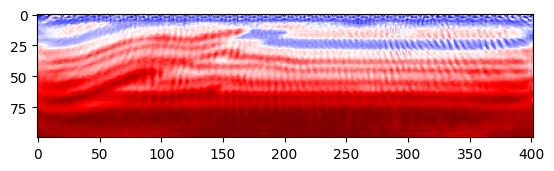

In [9]:
plt.imshow(model_dasia.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.show()

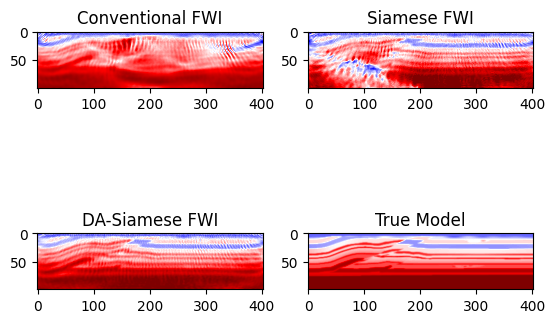

In [20]:
plt.subplot(2,2,1)
plt.imshow(model_fwi.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.title('Conventional FWI')
plt.subplot(2,2,2)
plt.imshow(model_sia.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.title('Siamese FWI')
plt.subplot(2,2,3)
plt.imshow(model_dasia.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.title('DA-Siamese FWI')
plt.subplot(2,2,4)
plt.imshow(true_model.cpu().detach().numpy(),cmap='seismic',vmin=600,vmax=6000)
plt.title('True Model')
plt.show()

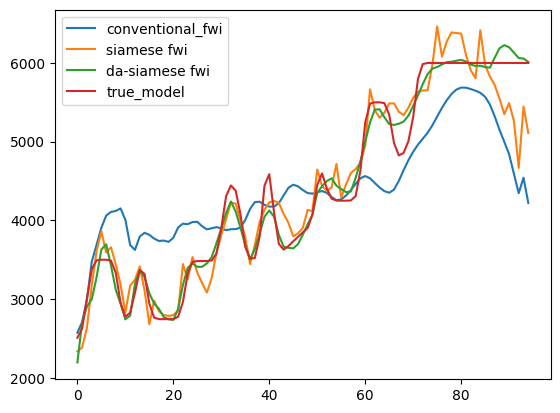

In [21]:
plt.plot(model_fwi.detach().cpu().numpy()[5:,200],label="conventional_fwi")
plt.plot(model_sia.detach().cpu().numpy()[5:,200],label="siamese fwi")
plt.plot(model_dasia.detach().cpu().numpy()[5:,200],label="da-siamese fwi")
plt.plot(true_model.detach().cpu().numpy()[5:,200],label="true_model")
plt.legend()
plt.show()